In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import ModelCheckpoint 
from tensorflow.keras.models import load_model

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Dense

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

from math import sqrt
import yfinance as yf
from datetime import date

In [55]:
start_date = "2024-01-01"
end_date = date.today().strftime("%Y-%m-%d")
dataFrame = yf.download('BTC-USD',start=start_date,end=end_date,interval='1d')
print(f"dữ liệu từ: {start_date} đến {end_date}:")

[*********************100%***********************]  1 of 1 completed

dữ liệu từ: 2024-01-01 đến 2026-05-17:


In [56]:
df = dataFrame.copy()

In [57]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2024-01-01,44167.332031,44175.437500,42214.976562,42280.234375,18426978443
2024-01-02,44957.968750,45899.707031,44176.949219,44187.140625,39335274536
2024-01-03,42848.175781,45503.242188,40813.535156,44961.601562,46342323118
2024-01-04,44179.921875,44770.023438,42675.175781,42855.816406,30448091210
2024-01-05,44162.691406,44353.285156,42784.718750,44192.980469,32336029347


In [58]:
df = df.reset_index()
df['Date'] = df['Date'].dt.strftime('%d-%m-%Y')

In [59]:
df.to_csv('bitcoin_dataset.csv',index=False,encoding='utf-8-sig')
print("đã xuất file thành công: bitcoin_dataset.csv")

đã xuất file thành công: bitcoin_dataset.csv


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Date, )           866 non-null    object 
 1   (Close, BTC-USD)   866 non-null    float64
 2   (High, BTC-USD)    866 non-null    float64
 3   (Low, BTC-USD)     866 non-null    float64
 4   (Open, BTC-USD)    866 non-null    float64
 5   (Volume, BTC-USD)  866 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 40.7+ KB


In [61]:
df.shape

(866, 6)

In [62]:
df.columns

MultiIndex([(  'Date',        ''),
            ( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [63]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,866.000000,866.000000,866.000000,866.000000,8.660000e+02
mean,82611.751398,84013.782811,81064.050281,82569.052631,4.454888e+10
std,20931.917476,21106.196584,20776.540439,20976.434465,2.327309e+10
min,39507.367188,40127.351562,38521.894531,39518.714844,9.344044e+09
25%,65972.539062,67295.044922,64582.336914,65961.160156,2.800127e+10
50%,82658.042969,84274.585938,80705.417969,82657.894531,4.024823e+10
75%,100011.988281,102372.126953,97513.343750,100041.427734,5.553371e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,1.817464e+11


In [65]:
import plotly.express as px
df.columns = df.columns.get_level_values(0)
fig = px.line(df, x='Date', y='Close', title='Xu hướng giá Bitcoin từ 01/01/2024')
fig.update_traces(line_color='blue') 
fig.update_layout(xaxis_title='Ngày', yaxis_title='Giá USD')
fig.show()

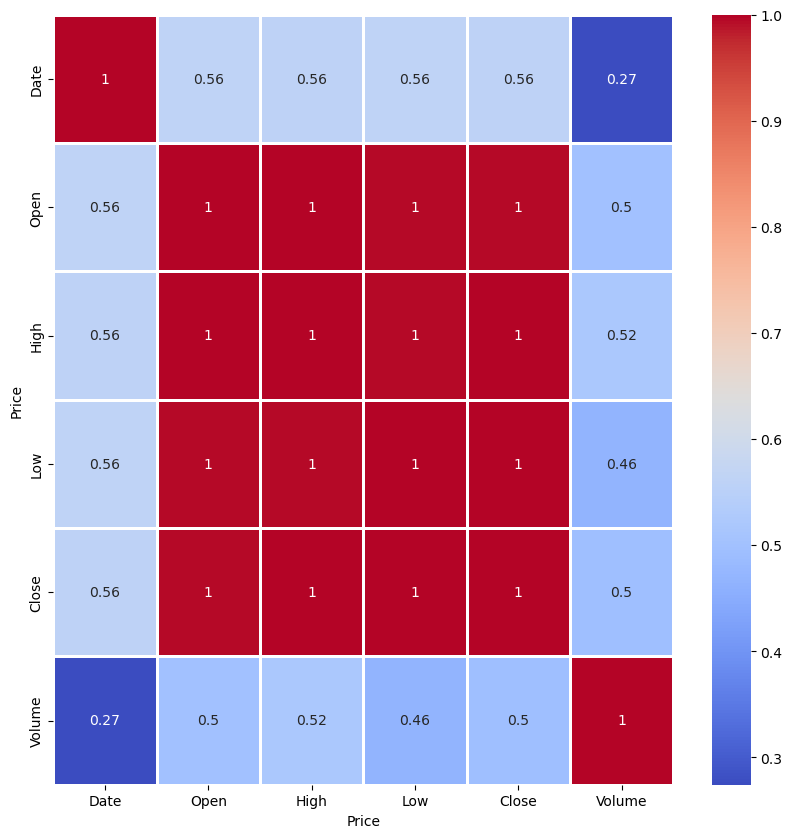

In [66]:
df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y')
df['Date'] = pd.to_datetime(df['Date'])
df['Date_num'] = df['Date'].map(pd.Timestamp.toordinal)
plt.figure(figsize=(10,10))
sns.heatmap(df[['Date','Open','High','Low','Close','Volume']].corr(),annot=True,cmap='coolwarm',linewidths=2
)
plt.show()

<Axes: xlabel='Price'>

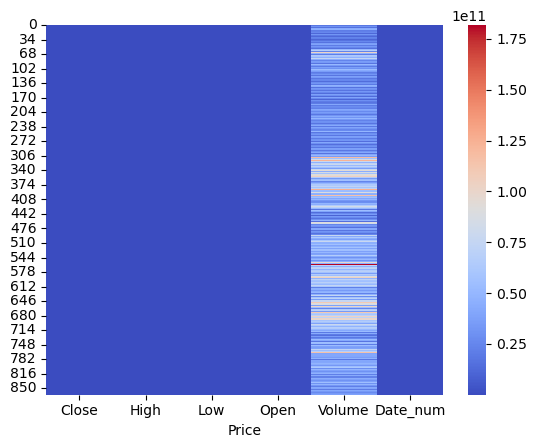

In [67]:
sns.heatmap(df.drop('Date', axis=1),cmap='coolwarm')

In [82]:
df['H-L'] = df['High'] - df['Low']
df['O-C'] = df['Open'] - df['Close']
ma_1 = 7
ma_2 = 17
ma_3 = 30

df[f'SMA_{ma_1}'] = df['Close'].rolling(window=ma_1).mean()
df[f'SMA_{ma_2}'] = df['Close'].rolling(window=ma_2).mean()
df[f'SMA_{ma_3}'] = df['Close'].rolling(window=ma_3).mean()

df[f'SD_{ma_1}'] = df['Close'].rolling(window=ma_1).std()
df[f'SD_{ma_3}'] = df['Close'].rolling(window=ma_3).std()
df.dropna(inplace=True)

df.to_csv(f"data_bitcon.csv",index=False)

In [85]:
features1 = ['Open', 'High', 'Low', 'Close', 'Volume']
features2 = [
    'H-L', 'O-C',
    f'SMA_{ma_1}',
    f'SMA_{ma_2}',
    f'SMA_{ma_3}',
    f'SD_{ma_1}',
    f'SD_{ma_3}'
]
features3 = features1 + features2
target = 'Close'

X1 = df[features1]
X2 = df[features2]
X3 = df[features3]

y = df[[target]]

train_size = int(len(df) * 0.8)

X1_train, X1_test = X1[:train_size], X1[train_size:]
X2_train, X2_test = X2[:train_size], X2[train_size:]
X3_train, X3_test = X3[:train_size], X3[train_size:]

y_train, y_test = y[:train_size], y[train_size:]

In [86]:
scaler_x1 = MinMaxScaler()
scaler_x2 = MinMaxScaler()
scaler_x3 = MinMaxScaler()

X1_train_scaled = scaler_x1.fit_transform(X1_train)
X1_test_scaled = scaler_x1.transform(X1_test)

X2_train_scaled = scaler_x2.fit_transform(X2_train)
X2_test_scaled = scaler_x2.transform(X2_test)

X3_train_scaled = scaler_x3.fit_transform(X3_train)
X3_test_scaled = scaler_x3.transform(X3_test)

scaler_y = MinMaxScaler()

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [87]:
X1_train_scaled = pd.DataFrame(X1_train_scaled, columns=features1, index=X1_train.index)
X1_test_scaled = pd.DataFrame(X1_test_scaled, columns=features1, index=X1_test.index)

X2_train_scaled = pd.DataFrame(X2_train_scaled, columns=features2, index=X2_train.index)
X2_test_scaled = pd.DataFrame(X2_test_scaled, columns=features2, index=X2_test.index)

X3_train_scaled = pd.DataFrame(X3_train_scaled, columns=features3, index=X3_train.index)
X3_test_scaled = pd.DataFrame(X3_test_scaled, columns=features3, index=X3_test.index)

y_train_scaled = pd.DataFrame(y_train_scaled, columns=[target], index=y_train.index)
y_test_scaled = pd.DataFrame(y_test_scaled, columns=[target], index=y_test.index)

<Axes: >

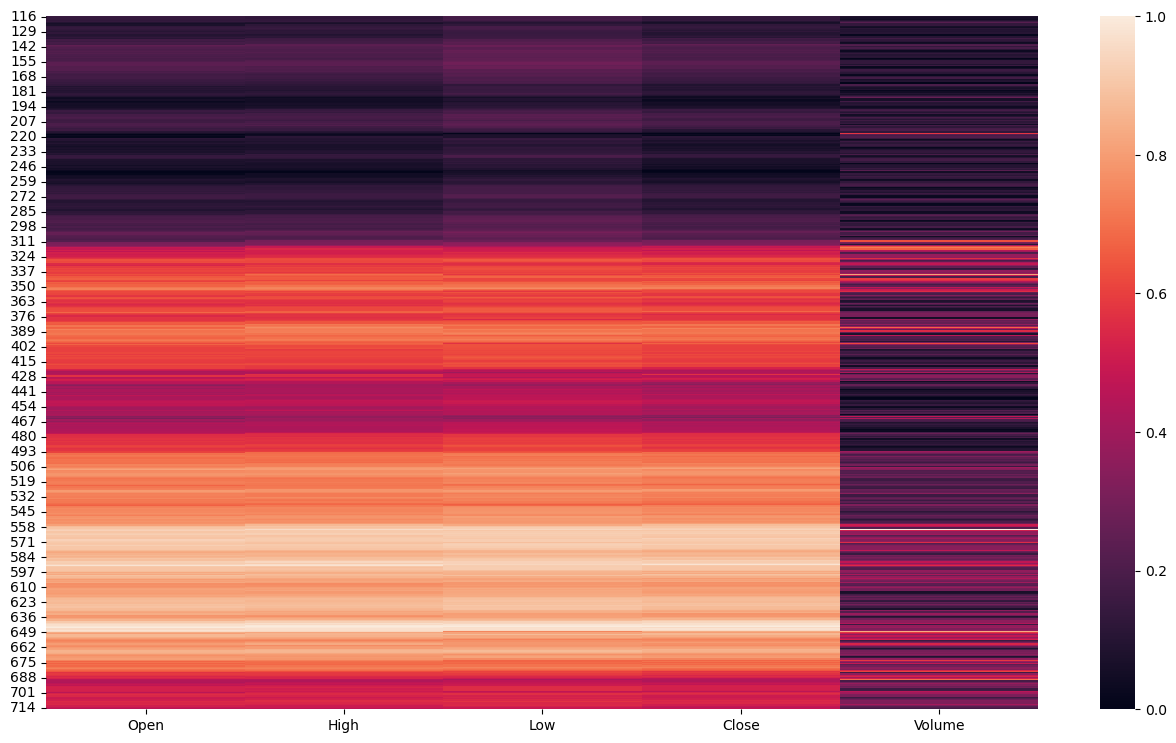

In [88]:
plt.figure(figsize=(16,9))
sns.heatmap(X1_train_scaled)

In [ ]:
def create_sequences(X, y, time_steps=30):
    Xs, ys = [], []

    for i in range(time_steps, len(X)):
        Xs.append(X.iloc[i-time_steps:i].values)
        ys.append(y.iloc[i].values)
    return np.array(Xs), np.array(ys)

In [90]:
time_steps = 30

X1_train_seq, y1_train_seq = create_sequences(X1_train_scaled, y_train_scaled, time_steps)
X1_test_seq, y1_test_seq = create_sequences(X1_test_scaled, y_test_scaled, time_steps)

X2_train_seq, y2_train_seq = create_sequences(X2_train_scaled, y_train_scaled, time_steps)
X2_test_seq, y2_test_seq = create_sequences(X2_test_scaled, y_test_scaled, time_steps)

X3_train_seq, y3_train_seq = create_sequences(X3_train_scaled, y_train_scaled, time_steps)
X3_test_seq, y3_test_seq = create_sequences(X3_test_scaled, y_test_scaled, time_steps)

In [ ]:
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(
        units=50,
        return_sequences=True,
        input_shape=input_shape
    ))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    return model

In [93]:
model1 = build_lstm_model((X1_train_seq.shape[1], X1_train_seq.shape[2]))
model2 = build_lstm_model((X2_train_seq.shape[1], X2_train_seq.shape[2]))
model3 = build_lstm_model((X3_train_seq.shape[1], X3_train_seq.shape[2]))

c:\Users\NKAQuoc002\anaconda3\envs\ML\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [94]:
history1 = model1.fit(
    X1_train_seq, y1_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

history2 = model2.fit(
    X2_train_seq, y2_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

history3 = model3.fit(
    X3_train_seq, y3_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0794 - val_loss: 0.0091
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0183 - val_loss: 0.0234
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0106 - val_loss: 0.0057
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0091 - val_loss: 0.0055
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0079 - val_loss: 0.0050
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0084 - val_loss: 0.0067
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0069 - val_loss: 0.0065
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0066 - val_loss: 0.0065
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0084 - val_loss: 0.0095
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0074 - val_loss: 0.0055
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0074 - val_loss: 0.0036
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0

In [107]:
pred1 = model1.predict(X1_test_seq)
pred2 = model2.predict(X2_test_seq)
pred3 = model3.predict(X3_test_seq)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [108]:
pred1_real = scaler_y.inverse_transform(pred1)
pred2_real = scaler_y.inverse_transform(pred2)
pred3_real = scaler_y.inverse_transform(pred3)

y_test_real = scaler_y.inverse_transform(y1_test_seq)

In [ ]:
y_true = y_test_real.flatten()
pred1 = pred1_real.flatten()
pred2 = pred2_real.flatten()
pred3 = pred3_real.flatten()

In [ ]:
compare_df = pd.DataFrame({
    "Thực tế": y_true,
    "Dự đoán Model 1": pred1,
    "Lệch Model 1": abs(y_true - pred1),
    "Dự đoán Model 2": pred2,
    "Lệch Model 2": abs(y_true - pred2),
    "Dự đoán Model 3": pred3,
    "Lệch Model 3": abs(y_true - pred3)
})

In [114]:
compare_df.head(20)

,Thực tế,Dự đoán Model 1,Lệch Model 1,Dự đoán Model 2,Lệch Model 2,Dự đoán Model 3,Lệch Model 3
0,95525.117188,94955.398438,569.718750,96475.812500,950.695312,95876.906250,351.789062
1,95099.921875,95704.781250,604.859375,97084.710938,1984.789062,96398.523438,1298.601562
2,93634.429687,96244.968750,2610.539063,97562.664062,3928.234375,96549.500000,2915.070313
3,92553.593750,96498.242188,3944.648438,97463.234375,4909.640625,95966.882812,3413.289062
4,88310.906250,96395.703125,8084.796875,97163.843750,8852.937500,95276.234375,6965.328125
5,89376.960938,95800.570312,6423.609375,95535.062500,6158.101562,93289.835938,3912.875000
6,89462.453125,94838.375000,5375.921875,95044.078125,5581.625000,92610.914062,3148.460938
7,89503.875000,93858.882812,4355.007812,94895.039062,5391.164062,92209.882812,2706.007812
8,89110.734375,93013.812500,3903.078125,94840.578125,5729.843750,91930.195312,2819.460938
9,86572.218750,92261.539062,5689.320312,94773.859375,8201.640625,91592.531250,5020.312500


In [109]:
def evaluate_model(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(name)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("-" * 30)

In [ ]:
evaluate_model(y_test_real, pred1_real, "Model 1 - OHLCV")
evaluate_model(y_test_real, pred2_real, "Model 2 - Feature mới")
evaluate_model(y_test_real, pred3_real, "Model 3 - sum feature 1 + 2")

Model 1 - OHLCV
RMSE: 3914.863415753856
MAE: 2747.48173828125
------------------------------
Model 2 - Feature mới
RMSE: 4443.185781389863
MAE: 3390.5060546875
------------------------------
Model 3 - sum model 1 + 2
RMSE: 3015.2399835937886
MAE: 2133.8723307291666
------------------------------


In [ ]:
import plotly.graph_objects as go

y_true = y_test_real.flatten()

pred1 = pred1_real.flatten()
pred2 = pred2_real.flatten()
pred3 = pred3_real.flatten()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=y_true,
        mode='lines',
        name='Giá thực tế',
        line=dict(color='blue')
    )
)

fig.add_trace(
    go.Scatter(
        y=pred1,
        mode='lines',
        name='Model 1 - OHLCV',
        line=dict(color='red')
    )
)

fig.add_trace(
    go.Scatter(
        y=pred2,
        mode='lines',
        name='Model 2 - Feature Engineering',
        line=dict(color='green')
    )
)

fig.add_trace(
    go.Scatter(
        y=pred3,
        mode='lines',
        name='Model 3 - Combined',
        line=dict(color='orange')
    )
)

fig.update_layout(
    title='So sánh dự đoán giá Bitcoin giữa 3 mô hình',
    xaxis_title='Thời gian',
    yaxis_title='Giá Close (USD)',
    template='plotly_white',
    width=1200,
    height=700
)

fig.show()